### To make a complete system, first we make them in ipynb and later make corresponding python .py files for each

#### AI Tutor is a multi-agent agentic system that follows multi-agent architecture.

##### We add multiple specialized agents to the AI Tutor that works autonomouly parallely or sequentially based upon the requirements to reach/achieve the goal. Supervisor being at the top makes the goal into sub-goals and provide the sub-goal to corresponding agents based upon the specialization

##### All the necessary imports are:

In [130]:
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
from langchain_groq import ChatGroq
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser
from pydantic import BaseModel, Field
from typing import Literal, TypedDict, Optional, List, Annotated
from langchain_ollama import OllamaEmbeddings
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage, AIMessage, BaseMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, START, END
from langgraph_supervisor import create_supervisor
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from langgraph.types import Command, Interrupt
from dotenv import load_dotenv
import os

In [110]:
load_dotenv()

True

### Supervisor and Workers:- 

##### We need to make a supervisor agent where all the workers agent that are going to work and their use are given to the supervisor using prompt so that it can make reasoning and then handsoff the corresponding agent.

##### The supervisor should route the task to the corresponding agent in such a way that the whole task could be done by the agent in and no other agent's capable work should be given to the agent. Such prompt should be given to the supervisor agent.

##### Each agent will get the task that only belongs to it and then when the agent does its work then the agent will change the state due to which the supervisor can get all the changes done by the agent and go for the next job to delegate.

##### It's just like the Orchestrator.

### tools

In [111]:
llm = ChatGroq(
    api_key=os.getenv("api_key"),
    model = os.getenv("model")
)

tavily_research_tool = TavilySearch(max_results=3, include_answer= True, search_depth= "advanced", auto_parameters=True)
tavily_research_tool.invoke({"query" : "What is llm?"})

{'query': 'What is llm?',
 'response_time': 2.22,
 'follow_up_questions': None,
 'answer': 'A large language model (LLM) is an advanced AI system that understands and generates human-like text based on extensive training data. LLMs are used for various natural language processing tasks. They are primarily transformer-based neural networks.',
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/Large_language_model',
   'title': 'Large language model - Wikipedia',
   'content': 'A large language model (LLM) is a language model trained with self-supervised machine learning on a vast amount of text, designed for natural language processing tasks, especially language generation. The largest and most capable LLMs are generative pre-trained transformers (GPTs) that provide the core capabilities of modern chatbots. LLMs can be fine-tuned "Fine-tuning (deep learning)") for specific tasks or guided by prompt engineering. These models acquire predictive power regarding syntax, sema

In [112]:
tools = [tavily_research_tool]

tools_by_name = {tool.name : tool for tool in tools}
print(tools_by_name)
llm_with_tools = llm.bind_tools([tavily_research_tool])

res = llm_with_tools.invoke([SystemMessage(content="think that you are an AI research agent and you have to make a decision to use the llm itself for answering or usng the correct tool among the available tools with all the approproate args required to it") ,"Who is the current pm of nepal?"])

print(f"Content:- {res.content}\n{'*'*140}\nReasoning:- {res.additional_kwargs['reasoning_content']}\n{'*'*140}\nTool Calls:- {res.tool_calls}\n{'*'*140}\n")

if res.content == "":
    res = tools_by_name[res.tool_calls[0]['name']].invoke(res.tool_calls[0])
    print(res)

{'tavily_search': TavilySearch(auto_parameters=True, search_depth='advanced', max_results=3, include_answer=True, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))}
Content:- 
********************************************************************************************************************************************
Reasoning:- The user asks: "Who is the current pm of Nepal?" This is a factual current event question. Need up-to-date info. Use search tool. We'll query for "current prime minister of Nepal". Use tavily_search.
********************************************************************************************************************************************
Tool Calls:- [{'name': 'tavily_search', 'args': {'query': 'current prime minister of Nepal', 'search_depth': 'fast', 'time_range': 'day'}, 'id': 'fc_4b24aae5-0713-4315-a407-96746305a2f2', 'type': 'tool_call'}]
***************************************************************************

In [133]:
# making dictionary for each of the agents tool

# research agent
research_tools = [tavily_research_tool]
research_tools_by_name = {tool.name : tool for tool in research_tools}

# task_specific_agent
materials_tools = []
materials_tools_by_name = {tool.name : tool for tool in materials_tools}

#rag_agent
rag_tools = []
rag_tools_by_name = {tool.name : tool for tool in rag_tools}

# youtube_agent
youtube_tools = []
youtube_tools_by_name = {tool.name : tool for tool in youtube_tools}

### LLM for each agents with tools binded to it

In [134]:
llm = ChatGroq(model= os.getenv("model"), api_key=os.getenv("api_key"))
research_agent_with_tool =  llm.bind_tools(research_tools)
rag_agent_with_tool = llm.bind_tools(rag_tools)
youtube_agent_with_tool = llm.bind_tools(youtube_tools)
task_agent_with_tool = llm.bind_tools(materials_tools)


In [ ]:
# BaseModels

class SubGoal(BaseModel):
    '''provided by the supervisor to the user'''
    pass

class Task(BaseModel):
    '''contains data of each data'''
    id : int = Field(description="id of the step")
    goal : int = Field(description="goal that the user needs to reach after reding the task's answer")
    research_flag : bool = Field("True if research tool is required and False if not")


class Plan(BaseModel):
    '''contains title of the sub-goal provided by the supervisor'''
    sub_goal : str
    task : List[Task]

class Research_agent_type(BaseModel):
    plan : Plan


class RAG_agent_type(BaseModel):
    pass


class Youtube_agent_type(BaseModel):
    pass


class Task_specific_type(BaseModel):
    pass



In [ ]:
# Main State

class State(TypedDict):
    goal : str
    title : str
    need_RAG : bool
    research_agent : Research_agent_type
    Youtube_agent : Youtube_agent_type
    Task_specific : Task_specific_type

class ResearchState(TypedDict):
    
    goal : str
    work : Research_agent_type
    
class MaterialsState(TypedDict):
    pass

class RAGState(TypedDict):
    pass

class YoutubeState(TypedDict):
    pass

In [117]:
def Planner(state : ResearchState):
    pass

def Researcher(state : ResearchState):
    pass

def ConditionalEdge(state : ResearchState):
    pass


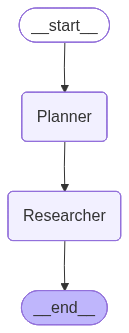

In [118]:
researchGraph = StateGraph(ResearchState)

researchGraph.add_node("Planner", Planner)
researchGraph.add_node("Researcher", Researcher)

researchGraph.add_edge(START, "Planner")
researchGraph.add_edge("Planner", "Researcher")
researchGraph.add_edge("Researcher", END)

ResearcherSubGraph = researchGraph.compile()
ResearcherSubGraph

In [119]:
def MiniSuervisor(state : MaterialsState):
    pass

def StudyPlanner(state : MaterialsState):
    pass

def QAandFlashCards(state : MaterialsState):
    pass

def SubAgentSelection(state : MaterialsState):
    if 1:
        return "QAandFlashCards"
    
    elif 2:
        return "StudyPlanner"
    
    elif 3:
        return "END"

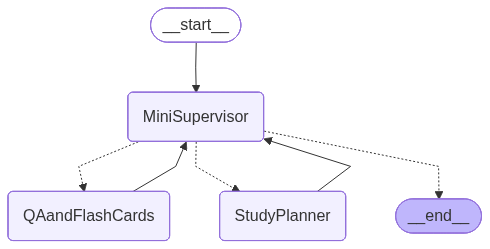

In [120]:
subGraph = StateGraph(State)
subGraph.add_node("MiniSupervisor", MiniSuervisor)
subGraph.add_node("StudyPlanner", StudyPlanner)
subGraph.add_node("QAandFlashCards", QAandFlashCards)

subGraph.add_edge(START, "MiniSupervisor")
subGraph.add_conditional_edges("MiniSupervisor", SubAgentSelection,{"QAandFlashCards" : "QAandFlashCards", "StudyPlanner" : "StudyPlanner"})
subGraph.add_edge("QAandFlashCards", "MiniSupervisor")
subGraph.add_edge("StudyPlanner", "MiniSupervisor")
subGraph.add_edge("MiniSupervisor", END)

subSystem = subGraph.compile()

subSystem

In [121]:
# FOR THE SUPERVISOR NODE
def Supervisor(state : State):
    pass

In [122]:
# FOR THE RESEARCH NODE
# it should be complex as its job is not only to extract one knowledge but many aspects like what, how, why, when, exmaples, mechanism etc.
def Researcher(state : State):
    response = ResearcherSubGraph.invoke({})

In [123]:
def YoutubeVideos(state : State):
    pass

In [124]:
# FOR THE YOUTUBEVIDEOS NODE
def Materials(state : State):
    # We make subgraph as it will contain multiple agents in side the TaskSpecific agent:
    # Sub-Supervisor
    # Worker Agents:
        # Q/A and FlashCards
        # StudyPlanner
    # All agents will have same tool as not needed much
    pass

In [125]:
# FOR THE RAG AGENT
def RAG(state : State):
    # this is a subgraph that contains a whole research-based, retriever, purifier, synthesizer
    pass

In [126]:
# at the end when all the task are completed then all the results from each agent are synthesized into proper format
def Synthesizer(state : State):
    # At last synthesize the whole blog/goal that are broken down and submitted to all the agents into one single organized form
    pass

In [127]:
def AgentSelection(state : State):
    if 1:
        return "Researcher"
    elif 2: 
        return "RAG"
    elif 3:
        return "Scrapper"
    elif 4:
        return "TaskSpecific"
    else:
        return "END"

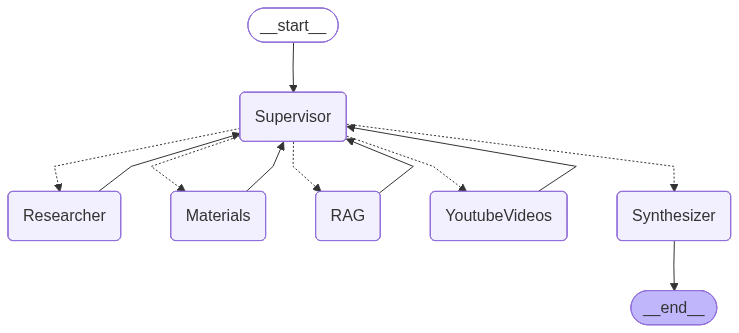

In [128]:
graph = StateGraph(State)
graph.add_node("Supervisor", Supervisor)
graph.add_node("Researcher", Researcher)
graph.add_node("Materials", Materials)    
graph.add_node("RAG", RAG)
graph.add_node("YoutubeVideos", YoutubeVideos)
graph.add_node("Synthesizer", Synthesizer)

graph.add_edge(START, "Supervisor")
graph.add_conditional_edges("Supervisor", AgentSelection, {"Researcher" : "Researcher", "RAG" : "RAG", "YoutubeVideos" : "YoutubeVideos", "Materials" : "Materials", "Synthesizer" : "Synthesizer"})
graph.add_edge("Researcher", "Supervisor")
graph.add_edge("RAG", "Supervisor")
graph.add_edge("Materials", "Supervisor")
graph.add_edge("YoutubeVideos", "Supervisor")
graph.add_edge("Synthesizer", END)

MainGraph = graph.compile()

MainGraph

